In [ ]:
import cv2
import numpy as np


v = cv2.VideoCapture('video/v.mp4')
if v.isOpened():
    open, frame = v.read()
else:
    open = False
frame_id = 0


In [ ]:
while open : # 视频循环
    re,frame = v.read()
    if not re:
        break
    frame_id += 1

    # 进行灰度化,去除颜色信息
    gray = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY) 
    # 切换到目标大小
    taget_size = (350,240)

    gray_goodshape = cv2.resize(gray,taget_size)

    # 进行高斯模糊,去除噪声
    blur = cv2.GaussianBlur(gray_goodshape,(3,3),0)

    # 进行直方图均衡化,增强对比度
    final = cv2.equalizeHist(blur)

    cv2.imshow('result',final)
    
    # 锁定第20帧
    if frame_id == 20:   
        cv2.waitKey(0)   
        break

    # 按下ESC键退出
    key = cv2.waitKey(25) & 0xFF 
    if key == 27:
        break
v.release()
cv2.destroyAllWindows()

# 运行的单帧结果

<div align="center">
    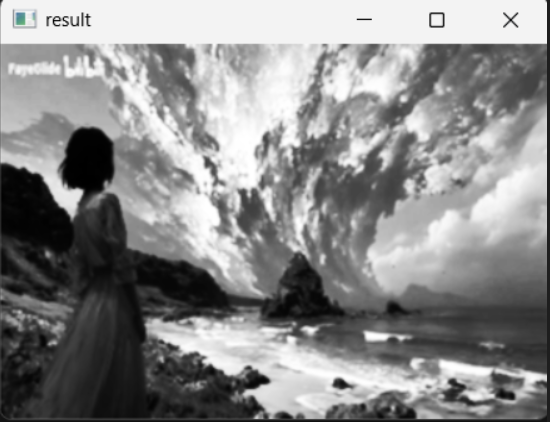
    <br>
    图一 - 第28帧的结果
</div>

# 体会与感悟

#### 知识获取
经过理解参考代码和询问AI,本次作业，我学到了常用的cv2的方法，包括使用cv读入图像、显示图像、等待键盘操作（方便退出窗口）、打开视频（VideoCapture）、读取一帧（使用While循环）、二值化、灰度变换、卷积函数、直方图均衡化。


#### 问题以及解决
主要问题在对于cv2的一些库函数和给库函数赋予的参数不熟悉，通过询问AI、做笔记的方式对这里进行了巩固。

在完成实验的过程
中也遇到了一些问题。————使用pip装numpy2.x导致和cv不兼容、错误的使用二值化而非灰度图像转化（由此巩固了三通道的知识）、没释放视频和关闭窗口导致崩溃必须重启、把release放到循环内部导致只有一帧视频。
由于对函数参数不熟悉，也出现了一些报错，通过查阅资料和询问AI逐步解决。



#### 感悟
做题期间，最初尝试读懂所有的参考代码再开始做题，但发现这样效率极低。
后来暂时放弃了深究数学原理和读懂所有代码，转向工程实践，有问题问AI，提升了自己的效率，并且在发现自己的程序跑起来的时候感到了满足。

2_1中的手写了直方图均衡化，但是cv其实有他可以直接调用的函数,我感受到API封装的方便之处
```python
final = cv2.equalizeHist(blur)
```
并且，还加深了我对“实践中学习”的理解